# beamfeat comparison with autofeat, OpenFE, featuretools and raw baselines

Nine datasets, eight methods, five splits: 360 fits.

The four feature builders — `autofeat`, `featuretools`, `openfe`,
`beamfeat_ridge` — hand their features to the same `RidgeCV`, so that
comparison is of the features alone. `beamfeat` is the estimator as shipped,
using its own internal ridge; reading it against `beamfeat_ridge` shows
whether the downstream model matters. The `*_raw` rows are reference points
on unengineered features.

Use the kernel from `setup_env.sh` and start Jupyter in this directory.

`FULL_RUN = False` reads the published results, about a minute. `True`
recomputes everything, 20-70 minutes, writing to `results_fresh_run/`.

## 1. Environment

In [1]:
import importlib.metadata as meta
import json, pathlib, sys, warnings
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

for name in ("numpy", "scikit-learn", "lightgbm", "autofeat", "openfe",
             "featuretools", "knockpy", "beamfeat"):
    print(f"{name:<14} {meta.version(name)}")
print(f"{'interpreter':<14} {sys.executable}")

numpy          1.26.4
scikit-learn   1.7.2
lightgbm       4.7.0
autofeat       2.1.3
openfe         0.0.12
featuretools   1.31.0
knockpy        1.3.2
beamfeat       0.1.1
interpreter    /home/dara/miniconda3/envs/af315/bin/python


## 2. Patch OpenFE

OpenFE 0.0.12 calls `mean_squared_error(squared=False)`, dropped in
scikit-learn 1.6, and passes a 2-D `init_score` that LightGBM 4 rejects. Two
one-line source fixes. Must run before anything imports OpenFE.

In [2]:
import importlib.util

pkg = pathlib.Path(importlib.util.find_spec("openfe").origin).parent
for fname in ("openfe.py", "FeatureSelector.py"):
    f = pkg / fname
    src = f.read_text()
    src = src.replace("from sklearn.metrics import mean_squared_error",
                      "from sklearn.metrics import mean_squared_error, root_mean_squared_error")
    src = src.replace("mean_squared_error(label, pred, squared=False)",
                      "root_mean_squared_error(label, pred)")
    src = src.replace("init_score=train_init,",
                      "init_score=__import__('numpy').asarray(train_init).ravel(),")
    src = src.replace("eval_init_score=[val_init],",
                      "eval_init_score=[__import__('numpy').asarray(val_init).ravel()],")
    f.write_text(src)

assert "openfe" not in sys.modules, "restart the kernel: OpenFE is already imported unpatched"
print("patched")

patched


## 3. Run

`bench.py` holds the datasets, the eight method wrappers and the fit loop.
The notebook calls it rather than repeating it, so the two cannot disagree.
Results go to `results_fresh_run/`, leaving the published
`results_as_reported/` untouched.

In [3]:
%%time
import bench

FULL_RUN = True   # True recomputes everything; 45-70 minutes

HERE = pathlib.Path(bench.__file__).resolve().parent
ARCHIVE, FRESH = HERE / "results_as_reported", HERE / "results_fresh_run"
RESULTS = FRESH if FULL_RUN else ARCHIVE

if FULL_RUN:
    FRESH.mkdir(exist_ok=True)
    fast = ["ridge_raw", "rf_raw", "lgbm_raw", "featuretools", "openfe",
            "beamfeat", "beamfeat_ridge"]
    for which, methods, out in (
        ("real", fast, "results_real_fast.json"),
        ("synthetic", fast, "results_syn_fast.json"),
        ("real", ["autofeat"], "results_real_autofeat.json"),
        ("synthetic", ["autofeat"], "results_syn_autofeat.json"),
    ):
        bench.main(which, methods, 5, str(FRESH / out))

concrete         ridge_raw     s0 R2=+0.6240     0.0s n_new=None
concrete         rf_raw        s0 R2=+0.9019     0.3s n_new=None
concrete         lgbm_raw      s0 R2=+0.9240     0.7s n_new=None
concrete         featuretools  s0 R2=+0.7430     0.4s n_new=84


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  6.36it/s]


concrete         openfe        s0 R2=+0.8137     5.2s n_new=20
concrete         beamfeat      s0 R2=+0.8524     0.8s n_new=21
concrete         beamfeat_ridge s0 R2=+0.8501     0.8s n_new=21
concrete         ridge_raw     s1 R2=+0.5552     0.0s n_new=None
concrete         rf_raw        s1 R2=+0.8999     0.4s n_new=None
concrete         lgbm_raw      s1 R2=+0.9312     0.7s n_new=None
concrete         featuretools  s1 R2=+0.8187     0.3s n_new=84


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  7.43it/s]


concrete         openfe        s1 R2=+0.7422     4.2s n_new=20
concrete         beamfeat      s1 R2=+0.8017     0.7s n_new=13
concrete         beamfeat_ridge s1 R2=+0.8003     0.7s n_new=13
concrete         ridge_raw     s2 R2=+0.5815     0.0s n_new=None
concrete         rf_raw        s2 R2=+0.9131     0.4s n_new=None
concrete         lgbm_raw      s2 R2=+0.9320     0.7s n_new=None
concrete         featuretools  s2 R2=+0.8414     0.3s n_new=84


...

friedman1        openfe        s2 R2=+0.8382     3.9s n_new=20
friedman1        beamfeat      s2 R2=+0.7910     0.7s n_new=13
friedman1        beamfeat_ridge s2 R2=+0.7888     0.7s n_new=13
friedman1        ridge_raw     s3 R2=+0.6862     0.0s n_new=None
friedman1        rf_raw        s3 R2=+0.8352     0.4s n_new=None
friedman1        lgbm_raw      s3 R2=+0.9100     0.5s n_new=None
friedman1        featuretools  s3 R2=+0.4508     0.2s n_new=135


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  9.16it/s]


friedman1        openfe        s3 R2=+0.8024     3.7s n_new=20
friedman1        beamfeat      s3 R2=+0.7371     0.7s n_new=14
friedman1        beamfeat_ridge s3 R2=+0.7321     0.7s n_new=14
friedman1        ridge_raw     s4 R2=+0.7073     0.0s n_new=None
friedman1        rf_raw        s4 R2=+0.8088     0.3s n_new=None
friedman1        lgbm_raw      s4 R2=+0.9019     0.5s n_new=None
friedman1        featuretools  s4 R2=+0.7135     0.5s n_new=135


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  9.29it/s]


friedman1        openfe        s4 R2=+0.7642     3.9s n_new=20
friedman1        beamfeat      s4 R2=+0.7530     0.7s n_new=19
friedman1        beamfeat_ridge s4 R2=+0.7584     0.8s n_new=19
wrote /home/dara/Downloads/beamFeat/beamFeat/benchmarks/independent/results_fresh_run/results_syn_fast.json
concrete         autofeat      s0 R2=+0.8682    30.2s n_new=58
concrete         autofeat      s1 R2=+0.8509    25.1s n_new=31
concrete         autofeat      s2 R2=+0.8917    24.0s n_new=45
concrete         autofeat      s3 R2=+0.9127    32.3s n_new=55
concrete         autofeat      s4 R2=+0.8888    30.8s n_new=55
wine_red         autofeat      s0 R2=+0.3554    38.4s n_new=14
wine_red         autofeat      s1 R2=+0.4283    36.9s n_new=16
wine_red         autofeat      s2 R2=+0.4031    36.6s n_new=9
wine_red         autofeat      s3 R2=+0.4225    37.8s n_new=14
wine_red         autofeat      s4 R2=+0.3732    40.9s n_new=14
boston           autofeat      s0 R2=+0.7367    57.3s n_new=38
boston    

## 4. Load

In [4]:
%%time
paths = sorted(RESULTS.glob("results_*.json"))
rows = []
for f in paths:
    rows += json.load(open(f))

df = pd.DataFrame(rows).drop_duplicates(["dataset", "method", "split"], keep="last")
n_err = int(df.error.notna().sum())
df = df[df.error.isna()]

ALL = ["ridge_raw", "rf_raw", "lgbm_raw", "featuretools", "openfe", "autofeat",
       "beamfeat", "beamfeat_ridge"]
ORDER = [m for m in ALL if m in set(df.method)]
REAL = ["concrete", "wine_red", "boston", "diabetes"]
SYNTH = [d for d in df.dataset.unique() if d not in REAL]
LABEL = {"ridge_raw": "ridge", "rf_raw": "random forest", "lgbm_raw": "LightGBM",
         "featuretools": "featuretools", "openfe": "OpenFE", "autofeat": "autofeat",
         "beamfeat": "beamfeat", "beamfeat_ridge": "beamfeat → ridge"}

print(f"{RESULTS.name}: {len(df)} fits, {df.dataset.nunique()} datasets, "
      f"{len(ORDER)} methods ({n_err} errored)")

missing = [m for m in ALL if m not in ORDER]
if missing and FULL_RUN:
    raise AssertionError(f"no successful fit for {missing}")
if missing:
    print(f"note: {missing} absent from this archive; set FULL_RUN = True to include them")

results_fresh_run: 360 fits, 9 datasets, 8 methods (0 errored)
CPU times: user 40.9 ms, sys: 141 ms, total: 182 ms
Wall time: 9.64 ms


## 5. Accuracy

In [5]:
def table(datasets):
    sub = df[df.dataset.isin(datasets)]
    mean = sub.pivot_table(index="dataset", columns="method", values="r2")
    std = sub.pivot_table(index="dataset", columns="method", values="r2", aggfunc="std")
    return mean[ORDER].round(3).astype(str) + " ± " + std[ORDER].round(3).astype(str)

print("REAL DATASETS (held-out R², mean ± std over 5 splits)")
display(table(REAL))
print("SYNTHETIC (known generating law)")
display(table(SYNTH))

REAL DATASETS (held-out R², mean ± std over 5 splits)


method,ridge_raw,rf_raw,lgbm_raw,featuretools,openfe,autofeat,beamfeat,beamfeat_ridge
dataset,,,,,,,,
boston,0.73 ± 0.06,0.866 ± 0.044,0.862 ± 0.064,-25.627 ± 20.289,0.729 ± 0.059,0.862 ± 0.071,0.833 ± 0.079,0.835 ± 0.08
concrete,0.583 ± 0.025,0.911 ± 0.009,0.932 ± 0.005,0.818 ± 0.047,0.754 ± 0.086,0.882 ± 0.024,0.845 ± 0.025,0.845 ± 0.026
diabetes,0.428 ± 0.04,0.324 ± 0.064,0.208 ± 0.051,0.28 ± 0.084,0.427 ± 0.039,-0.274 ± 1.479,0.423 ± 0.038,0.425 ± 0.038
wine_red,0.362 ± 0.009,0.479 ± 0.028,0.418 ± 0.047,0.396 ± 0.022,0.38 ± 0.014,0.397 ± 0.031,0.382 ± 0.025,0.382 ± 0.026


SYNTHETIC (known generating law)


method,ridge_raw,rf_raw,lgbm_raw,featuretools,openfe,autofeat,beamfeat,beamfeat_ridge
dataset,,,,,,,,
friedman1,0.712 ± 0.029,0.816 ± 0.012,0.899 ± 0.008,-2.132 ± 6.011,0.796 ± 0.028,-19.891 ± 46.596,0.746 ± 0.028,0.746 ± 0.027
kinetic:m*v^2/2,0.858 ± 0.008,0.989 ± 0.006,0.991 ± 0.003,0.995 ± 0.001,0.88 ± 0.012,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
linear_ctrl,1.0 ± 0.0,0.976 ± 0.003,0.988 ± 0.002,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,0.999 ± 0.0,0.999 ± 0.0
sparse10:a*b,0.901 ± 0.01,0.987 ± 0.002,0.989 ± 0.001,0.996 ± 0.0,0.901 ± 0.011,0.997 ± 0.0,0.997 ± 0.0,0.997 ± 0.0
three_way:a*b/c,0.759 ± 0.018,0.943 ± 0.013,0.894 ± 0.039,0.975 ± 0.01,0.759 ± 0.019,0.975 ± 0.012,1.0 ± 0.0,1.0 ± 0.0


## 6. Cost, parsimony and recovery

`recovery` is the fraction of scoreable synthetic fits in which some returned
feature referenced all of the generating columns. It is column recovery, not
symbolic recovery — see the docstring in `bench.py`. Blank where a method
returns no inspectable formulas.

In [6]:
summary = pd.DataFrame({
    "seconds": df.groupby("method").seconds.mean(),
    "features": df.groupby("method").n_new.mean(),
    "recovery": df.dropna(subset=["recovered"]).groupby("method").recovered.mean(),
    "worst R²": df.groupby("method").r2.min(),
    "mean R²": df.groupby("method").r2.mean(),
    "fits below 0": df.groupby("method").r2.apply(lambda v: int((v < 0).sum())),
}).loc[ORDER].round(3)
display(summary)

b = df[df.method == "beamfeat"]
print(f"beamfeat fdr_controlled_ true on {int(b.fdr.sum())}/{len(b)} fits")

,seconds,features,recovery,worst R²,mean R²,fits below 0
method,,,,,,
ridge_raw,0.010,NaN,NaN,0.353,0.704,0
rf_raw,0.339,NaN,NaN,0.247,0.810,0
lgbm_raw,0.460,NaN,NaN,0.117,0.798,0
featuretools,0.260,104.667,NaN,-57.320,-2.478,6
openfe,3.822,7.333,NaN,0.360,0.736,0
autofeat,32.315,16.778,0.666667,-103.245,-1.561,2
beamfeat,0.517,9.156,1.0,0.355,0.803,0
beamfeat_ridge,0.553,9.156,1.0,0.355,0.803,0


beamfeat fdr_controlled_ true on 45/45 fits


## 7. Statistical comparison

Ranks and the omnibus test use one beamfeat entry: two would split the rank
space and make the figures incomparable with a seven-method analysis. The
paired Wilcoxon tests then compare `beamfeat` against every other method on
the 45 dataset-split pairs. With nine datasets the omnibus is underpowered,
so the paired tests carry the weight.

In [7]:
from scipy.stats import friedmanchisquare, rankdata, wilcoxon

RANKED = [m for m in ORDER if m != "beamfeat_ridge"]
piv = df.pivot_table(index="dataset", columns="method", values="r2")[RANKED]
ranks = pd.DataFrame([rankdata(-r.values) for _, r in piv.iterrows()], columns=RANKED)
print(f"average rank over {len(RANKED)} methods (1 = best)")
print(ranks.mean().sort_values().round(2).to_string())

chi, p = friedmanchisquare(*[piv[m].values for m in RANKED])
print(f"\nFriedman: chi2 = {chi:.2f}, p = {p:.4f} "
      f"({piv.shape[0]} datasets x {len(RANKED)} methods)")

base = df[df.method == "beamfeat"].set_index(["dataset", "split"]).r2
print("\npaired Wilcoxon, positive difference favours beamfeat")
for m in ORDER:
    if m == "beamfeat":
        continue
    other = df[df.method == m].set_index(["dataset", "split"]).r2
    common = base.index.intersection(other.index)
    delta = base[common] - other[common]
    print(f"  vs {LABEL.get(m, m):<16} n={len(common):>3}  median {np.median(delta):+.4f}"
          f"  mean {delta.mean():+.4f}  p = {wilcoxon(base[common], other[common]).pvalue:.4f}")

average rank over 7 methods (1 = best)
beamfeat        3.22
rf_raw          3.44
lgbm_raw        3.44
autofeat        3.67
featuretools    4.22
openfe          4.78
ridge_raw       5.22

Friedman: chi2 = 6.71, p = 0.3481 (9 datasets x 7 methods)

paired Wilcoxon, positive difference favours beamfeat
  vs ridge            n= 45  median +0.0878  mean +0.0990  p = 0.0000
  vs random forest    n= 45  median +0.0095  mean -0.0076  p = 0.5991
  vs LightGBM         n= 45  median +0.0074  mean +0.0047  p = 0.8581
  vs featuretools     n= 45  median +0.0080  mean +3.2805  p = 0.0000
  vs OpenFE           n= 45  median +0.0572  mean +0.0663  p = 0.0001
  vs autofeat         n= 45  median -0.0001  mean +2.3641  p = 0.0589
  vs beamfeat → ridge n= 45  median -0.0000  mean -0.0006  p = 0.0997


## 8. Does the downstream model matter?

`beamfeat` predicts through its own internal ridge at a fixed alpha;
`beamfeat_ridge` feeds the same constructed features to the shared `RidgeCV`.
If the two agree, the result comes from the features rather than the
estimator.

In [8]:
if "beamfeat_ridge" in ORDER:
    a = df[df.method == "beamfeat"].set_index(["dataset", "split"]).r2
    c = df[df.method == "beamfeat_ridge"].set_index(["dataset", "split"]).r2
    common = a.index.intersection(c.index)
    d = (a[common] - c[common]).abs()
    print(f"{len(common)} paired fits")
    print(f"  largest absolute difference: {d.max():.5f}")
    print(f"  median absolute difference:  {d.median():.5f}")
    print(f"  fits differing by more than 0.01: {int((d > 0.01).sum())}")
else:
    print("beamfeat_ridge not present in this results set")

45 paired fits
  largest absolute difference: 0.01632
  median absolute difference:  0.00033
  fits differing by more than 0.01: 2


## 9. Every fit

A mean hides the failures that matter. One dot per fit, columns ordered by
median, symmetric log below 1 so a catastrophic fit stays on the axis instead
of being clipped.

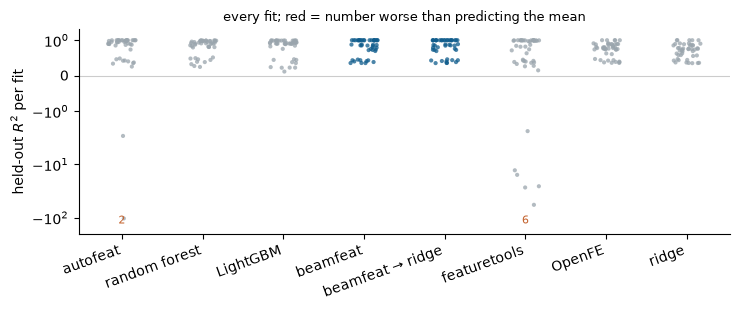

In [9]:
ACCENT, GREY, WARN = "#0F5C8C", "#9AA5AD", "#C4622D"
by_median = df.groupby("method").r2.median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7.5, 3.2))
rng = np.random.default_rng(0)
for i, m in enumerate(by_median):
    v = df[df.method == m].r2.dropna().to_numpy()
    ax.scatter(i + rng.uniform(-.17, .17, len(v)), v, s=9, alpha=.75, edgecolor="none",
               color=ACCENT if m.startswith("beamfeat") else GREY)
    if (v < 0).any():
        ax.annotate(f"{int((v < 0).sum())}", (i, .05), xycoords=("data", "axes fraction"),
                    ha="center", fontsize=8, color=WARN)
ax.axhline(0, color="#CCCCCC", lw=.8)
ax.set_yscale("symlog", linthresh=1.0, linscale=.6)
ax.set_xticks(range(len(by_median)))
ax.set_xticklabels([LABEL.get(m, m) for m in by_median], rotation=20, ha="right")
ax.set_ylabel("held-out $R^2$ per fit")
ax.set_ylim(min(-200, df.r2.min() * 1.5), 1.6)
ax.set_title("every fit; red = number worse than predicting the mean", fontsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Accuracy against cost

Mean held-out R² against mean fit time. No error bars: the spread across the
45 fits is dominated by differences between the nine datasets rather than by
uncertainty about a method, so an interval drawn from it would invite the
wrong reading.

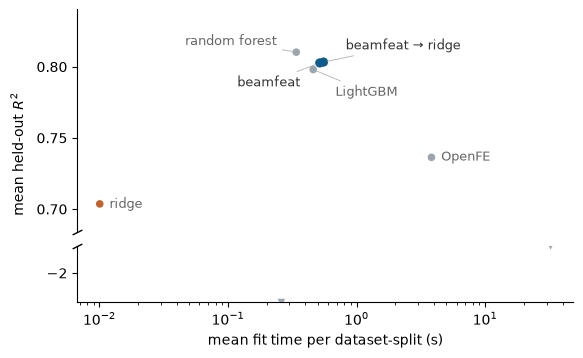

In [10]:
from matplotlib.ticker import FormatStrFormatter, MultipleLocator

s = df.groupby("method").agg(r2=("r2", "mean"), secs=("seconds", "mean"))

# Methods far below the rest go to a broken-axis lower panel at true scale.
FAIL_CUT = 0.68
ok, bad = s[s.r2 >= FAIL_CUT], s[s.r2 < FAIL_CUT]

fig, (ax, axb) = plt.subplots(2, 1, sharex=True, figsize=(6.4, 3.8),
                              gridspec_kw={"height_ratios": (4, 1), "hspace": 0.1})

# Upper panel: limits hug the data; direct labels, de-overlapped automatically.
ax.set_ylim(ok.r2.min() - 0.02, ok.r2.max() + 0.03)
ax.yaxis.set_major_locator(MultipleLocator(0.05))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
NUDGE = {                      # (dx, dy) pts; dx < 0 flips the label left
    "rf_raw":         (-14, 8),
    "beamfeat":       (-14, -14),
    "beamfeat_ridge": (16, 12),
    "lgbm_raw":       (16, -16),
}
for m, r in ok.iterrows():
    acc = m.startswith("beamfeat")
    col = ACCENT if acc else WARN if m == "ridge_raw" else GREY
    ax.scatter(r.secs, r.r2, s=44 if acc else 30, zorder=3,
               color=col, edgecolor="none")
    dx, dy = NUDGE.get(m, (7, 0))
    ax.annotate(LABEL.get(m, m), (r.secs, r.r2), textcoords="offset points",
                xytext=(dx, dy), ha="left" if dx >= 0 else "right",
                va="center", fontsize=9,
                color="#333333" if acc else "#666666",
                arrowprops=dict(arrowstyle="-", color="#b0b0b0", lw=.6,
                                shrinkA=2, shrinkB=3)
                if abs(dx) + abs(dy) > 18 else None)

# Lower panel: failures at their actual value.
for m, r in bad.iterrows():
    axb.scatter(r.secs, r.r2, s=30, zorder=3, color=GREY, marker="v",
                edgecolor="none")
    axb.annotate(f"{LABEL.get(m, m)} (R² = {r.r2:.2f})", (r.secs, r.r2),
                 textcoords="offset points", xytext=(-9, 0), ha="right",
                 va="center", fontsize=9, color="#666666")
if len(bad):
    mid = bad.r2.mean()
    axb.set_ylim(mid - .45, mid + .45)
    axb.set_yticks([round(mid, 1)])

ax.set_xscale("log")
axb.set_xlabel("mean fit time per dataset-split (s)")
fig.supylabel("mean held-out $R^2$", fontsize=10)
for sp in ("top", "right", "bottom"):
    ax.spines[sp].set_visible(False)
for sp in ("top", "right"):
    axb.spines[sp].set_visible(False)
ax.tick_params(axis="x", which="both", bottom=False)

# Axis-break marks.
brk = dict(marker=[(-1, -.5), (1, .5)], markersize=7, linestyle="none",
           color="k", mec="k", mew=1, clip_on=False)
ax.plot([0], [0], transform=ax.transAxes, **brk)
axb.plot([0], [1], transform=axb.transAxes, **brk)

fig.savefig("speed_panel.pdf", bbox_inches="tight")
plt.show()

## 11. Was the construction worth it?

Mean features constructed against mean held-out R². Every point here shares
the same downstream model, a `RidgeCV` on standardised features, so the only
difference between them is which features were constructed; `beamfeat_ridge`
is used rather than `beamfeat` for that reason. The dashed line is that same
ridge on the raw columns, so anything below it did more harm than constructing
nothing at all.

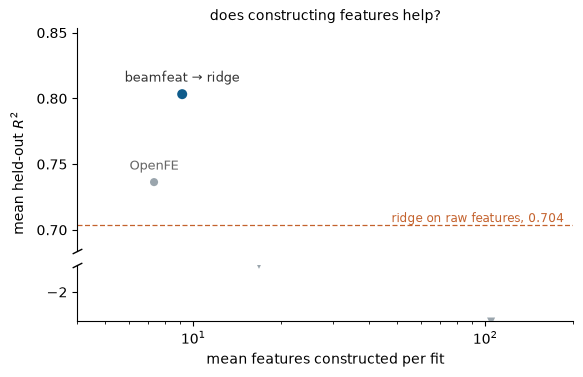

                  feats     r2
method                        
autofeat         16.778 -1.561
beamfeat_ridge    9.156  0.803
featuretools    104.667 -2.478
openfe            7.333  0.736

raw-ridge anchor: 0.704
below the anchor: ['autofeat', 'featuretools']


In [11]:
# Rows feeding the shared RidgeCV; beamfeat predicts through its own ridge.
builders = df[df.n_new.notna() & (df.method != "beamfeat")]
eff = builders.groupby("method").agg(feats=("n_new", "mean"), r2=("r2", "mean"))
if eff.empty:
    raise SystemExit("no constructor rows share the downstream model; run with FULL_RUN = True")
anchor = df[df.method == "ridge_raw"].r2.mean()

# Methods far below the anchor go to a broken-axis lower panel at true scale.
FAIL_CUT = anchor - 0.2
ok, bad = eff[eff.r2 >= FAIL_CUT], eff[eff.r2 < FAIL_CUT]

fig, (ax, axb) = plt.subplots(2, 1, sharex=True, figsize=(6.4, 3.8),
                              gridspec_kw={"height_ratios": (4, 1), "hspace": 0.1})

# Upper panel: limits hug the data.
ax.set_ylim(min(anchor, ok.r2.min()) - 0.02, ok.r2.max() + 0.05)
ax.yaxis.set_major_locator(MultipleLocator(0.05))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax.axhline(anchor, color=WARN, lw=.9, ls=(0, (4, 2)), zorder=1)
ax.text(.99, anchor, f"ridge on raw features, {anchor:.3f} ",
        transform=ax.get_yaxis_transform(), ha="right", va="bottom",
        fontsize=8.5, color=WARN)
for m, r in ok.iterrows():
    acc = m.startswith("beamfeat")
    ax.scatter(r.feats, r.r2, s=52 if acc else 34, zorder=3,
               color=ACCENT if acc else GREY, edgecolor="none")
    ax.annotate(LABEL.get(m, m), (r.feats, r.r2), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=9,
                color="#333333" if acc else "#666666")

# Lower panel: failures at their actual value.
for m, r in bad.iterrows():
    axb.scatter(r.feats, r.r2, s=34, zorder=3, color=GREY, marker="v",
                edgecolor="none")
    axb.annotate(f"{LABEL.get(m, m)} (R² = {r.r2:.2f})", (r.feats, r.r2),
                 textcoords="offset points", xytext=(-9, 0), ha="right",
                 va="center", fontsize=9, color="#666666")
if len(bad):
    mid = bad.r2.mean()
    axb.set_ylim(mid - .45, mid + .45)
    axb.set_yticks([round(mid, 1)])

ax.set_xscale("log")
ax.set_xlim(4, 200)
ax.set_title("does constructing features help?", fontsize=10)
axb.set_xlabel("mean features constructed per fit")
fig.supylabel("mean held-out $R^2$", fontsize=10)
for sp in ("top", "right", "bottom"):
    ax.spines[sp].set_visible(False)
for sp in ("top", "right"):
    axb.spines[sp].set_visible(False)
ax.tick_params(axis="x", which="both", bottom=False)

# Axis-break marks.
brk = dict(marker=[(-1, -.5), (1, .5)], markersize=7, linestyle="none",
           color="k", mec="k", mew=1, clip_on=False)
ax.plot([0], [0], transform=ax.transAxes, **brk)
axb.plot([0], [1], transform=axb.transAxes, **brk)

fig.savefig("feature_panel.pdf", bbox_inches="tight")
plt.show()
print(eff.round(3).to_string())
print(f"\nraw-ridge anchor: {anchor:.3f}")
print("below the anchor:",
      [m for m, r in eff.iterrows() if r.r2 < anchor] or "none")